In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
%matplotlib inline

In [3]:
df = pd.read_csv('https://raw.githubusercontent.com/alexeygrigorev/datasets/master/course_lead_scoring.csv')
df.head()

,lead_source,industry,number_of_courses_viewed,annual_income,employment_status,location,interaction_count,lead_score,converted
0,paid_ads,NaN,1,79450.0,unemployed,south_america,4,0.94,1
1,social_media,retail,1,46992.0,employed,south_america,1,0.80,0
2,events,healthcare,5,78796.0,unemployed,australia,3,0.69,1
3,paid_ads,retail,2,83843.0,NaN,australia,1,0.87,0
4,referral,education,3,85012.0,self_employed,europe,3,0.62,1


In [4]:
df.isnull().sum()

lead_source                 128
industry                    134
number_of_courses_viewed      0
annual_income               181
employment_status           100
location                     63
interaction_count             0
lead_score                    0
converted                     0
dtype: int64

In [7]:
categorical = list(df.dtypes[df.dtypes == 'str'].index)
numerical = list(df.dtypes[df.dtypes != 'str'].index)
df[categorical] = df[categorical].fillna('NA')
df[numerical] = df[numerical].fillna(0.0)

In [9]:
from sklearn.model_selection import train_test_split
df_train, df_temp = train_test_split(df, test_size = 0.4, random_state=1)
df_val, df_test = train_test_split(df_temp, test_size = 0.5, random_state=1)
df_train.shape, df_val.shape, df_test.shape

((877, 9), (292, 9), (293, 9))

In [11]:
y_train = df_train.converted.values
y_val = df_val.converted.values
y_test = df_test.converted.values

del df_train['converted']
del df_val['converted']
del df_test['converted']

### Question 1: ROC AUC feature importance

ROC AUC could also be used to evaluate feature importance of numerical variables.

Let's do that

For each numerical variable, use it as score (aka prediction) and compute the AUC with the y variable as ground truth.
Use the training dataset for that
If your AUC is < 0.5, invert this variable by putting "-" in front

(e.g. -df_train['balance'])

AUC can go below 0.5 if the variable is negatively correlated with the target variable. You can change the direction of the correlation by negating this variable - then negative correlation becomes positive.

Which numerical variable (among the following 4) has the highest AUC?

lead_score
number_of_courses_viewed
interaction_count
annual_income

In [14]:
from sklearn.metrics import roc_auc_score
scores = {}
for var in numerical:
    if var != 'converted':
        score = roc_auc_score(y_train, df_train[var].values)
        scores[var] = score

scores

{'number_of_courses_viewed': 0.7652439024390244,
 'annual_income': 0.5446354552990968,
 'interaction_count': 0.7271914132379249,
 'lead_score': 0.6111168681007025}

In [16]:
sorted(scores, key = lambda x: x[1], reverse = True)

['number_of_courses_viewed',
 'annual_income',
 'interaction_count',
 'lead_score']

### Question 2: Training the model

- Apply one-hot-encoding using DictVectorizer and train the logistic regression with these parameters:

- LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)

What's the AUC of this model on the validation dataset? (round to 3 digits)

In [24]:
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression

train_dict = df_train.to_dict(orient = 'records')
val_dict = df_val.to_dict(orient = 'records')
test_dict = df_test.to_dict(orient = 'records')
dv = DictVectorizer(sparse = False)
X_train = dv.fit_transform(train_dict)
X_val = dv.transform(val_dict)


In [28]:
model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict_proba(X_val)[:, 1]

In [31]:
from sklearn.metrics import roc_auc_score
round(roc_auc_score(y_val, y_pred),3)

0.794

### Question 3: Precision and Recall

Now let's compute precision and recall for our model.

- Evaluate the model on all thresholds from 0.0 to 1.0 with step 0.01
- For each threshold, compute precision and recall
- Plot them

At which threshold precision and recall curves intersect?

/var/folders/sy/21ppk3x56ml1y8st5k1mfhxh0000gn/T/ipykernel_59456/3698597186.py:13: RuntimeWarning: invalid value encountered in scalar divide
  p = tp / (tp + fp)


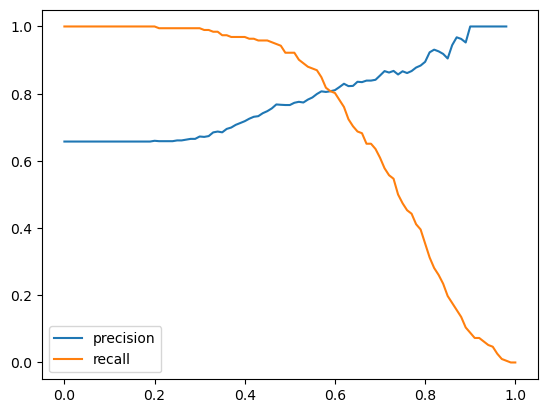

In [54]:
scores = []

actual_pos = y_val == 1
actual_neg = y_val == 0

for t in np.linspace(0.0, 1.0, 101):
    pred_pos = y_pred >= t
    pred_neg = y_pred < t
    tp = (actual_pos & pred_pos).sum()
    tn = (actual_neg & pred_neg).sum()
    fp = (actual_neg & pred_pos).sum()
    fn = (actual_pos & pred_neg).sum()
    p = tp / (tp + fp)
    r = tp / (tp + fn)

    scores.append([t, tp, tn, fp, fn, p, r])

    
df_scores = pd.DataFrame(scores, columns = ['threshold', 'true_positive', 'true_negative', 'false_positive', 'false_negative', 
                      'precision', 'recall'])

plt.plot(df_scores.threshold, df_scores.precision, label = 'precision')
plt.plot(df_scores.threshold, df_scores.recall, label = 'recall')    
plt.legend()

### Question 4: F1 score

Precision and recall are conflicting - when one grows, the other goes down. That's why they are often combined into the F1 score - a metrics that takes into account both

This is the formula for computing F1:

F1 = 2 (P * R) / (P + R)

Where P is precision and R is recall.

Let's compute F1 for all thresholds from 0.0 to 1.0 with increment 0.01

At which threshold F1 is maximal?

/var/folders/sy/21ppk3x56ml1y8st5k1mfhxh0000gn/T/ipykernel_59456/2088309520.py:13: RuntimeWarning: invalid value encountered in scalar divide
  p = tp / (tp + fp)


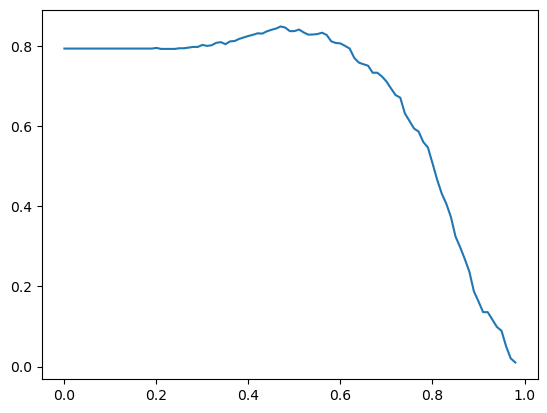

In [55]:
scores = []

actual_pos = y_val == 1
actual_neg = y_val == 0

for t in np.linspace(0.0, 1.0, 101):
    pred_pos = y_pred >= t
    pred_neg = y_pred < t
    tp = (actual_pos & pred_pos).sum()
    tn = (actual_neg & pred_neg).sum()
    fp = (actual_neg & pred_pos).sum()
    fn = (actual_pos & pred_neg).sum()
    p = tp / (tp + fp)
    r = tp / (tp + fn)
    F1 = 2 * (p * r) / (p + r)

    scores.append([t, tp, tn, fp, fn, p, r, F1])

    
df_scores = pd.DataFrame(scores, columns = ['threshold', 'true_positive', 'true_negative', 'false_positive', 'false_negative', 
                      'precision', 'recall', 'F1'])

plt.plot(df_scores.threshold, df_scores.F1, label = 'F1')

### Question 5: 5-Fold CV

Use the KFold class from Scikit-Learn to evaluate our model on 5 different folds:

```
KFold(n_splits=5, shuffle=True, random_state=1)
```
- Iterate over different folds of df_full_train
- Split the data into train and validation
- Train the model on train with these parameters: LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)
- Use AUC to evaluate the model on validation
  
How large is standard deviation of the scores across different folds?

In [64]:
from sklearn.model_selection import KFold

df = pd.read_csv('https://raw.githubusercontent.com/alexeygrigorev/datasets/master/course_lead_scoring.csv')
categorical = list(df.dtypes[df.dtypes == 'str'].index)
numerical = list(df.dtypes[df.dtypes != 'str'].index)
df[categorical] = df[categorical].fillna('NA')
df[numerical] = df[numerical].fillna(0.0)

df_full_train, _ = train_test_split(df, test_size = 0.8, random_state=1)
y_full_train = df_full_train['converted']


kf = KFold(n_splits=5, shuffle=True, random_state=1)

scores = []

for train_idx, val_idx in kf.split(df_full_train):
    train_df = df_full_train.iloc[train_idx]
    val_df = df_full_train.iloc[val_idx]

    del train_df['converted']
    del val_df['converted']

    y_train = y_full_train.iloc[train_idx]
    y_val = y_full_train.iloc[val_idx]
    
    dv = DictVectorizer(sparse = False)
    train_dict = train_df.to_dict(orient = 'records')
    val_dict = val_df.to_dict(orient = 'records')

    X_train = dv.fit_transform(train_dict)
    X_val = dv.transform(val_dict)

    model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)
    model.fit(X_train, y_train)

    y_pred = model.predict_proba(X_val)[:, 1]

    scores.append(roc_auc_score(y_val, y_pred))


In [67]:
np.std(scores)

np.float64(0.06457596907455893)

### Question 6: Hyperparameter Tuning

Now let's use 5-Fold cross-validation to find the best parameter C

- Iterate over the following C values: [0.000001, 0.001, 1]
- Initialize KFold with the same parameters as previously
- Use these parameters for the model: LogisticRegression(solver='liblinear', C=C, max_iter=1000)
- Compute the mean score as well as the std (round the mean and std to 3 decimal digits)

Which C leads to the best mean score?

In [82]:

for c in [0.000001, 0.001, 1]:
    kf = KFold(n_splits=5, shuffle=True, random_state=1)
    scores = []
    
    for train_idx, val_idx in kf.split(df_full_train):
        train_df = df_full_train.iloc[train_idx]
        val_df = df_full_train.iloc[val_idx]
    
        y_train = y_full_train.iloc[train_idx]
        y_val = y_full_train.iloc[val_idx]

        del train_df['converted']
        del val_df['converted']
        
        dv = DictVectorizer(sparse=False)
        train_dict = train_df.to_dict(orient = 'records')
        val_dict = val_df.to_dict(orient = 'records')
    
        X_train = dv.fit_transform(train_dict)
        X_val = dv.transform(val_dict)
    
        model = LogisticRegression(solver='liblinear', C=c, max_iter=1000)
        model.fit(X_train, y_train)
    
        y_pred = model.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, y_pred)
        scores.append(auc)
    # note the indentation of print!!!!!!!!!
    
    print('C=%s %.3f +- %.3f' % (c, np.mean(scores), np.std(scores)))

C=1e-06 0.570 +- 0.038
C=0.001 0.840 +- 0.029
C=1 0.805 +- 0.065
